In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

## Wczytywanie dataset, z których będziemy korzystać

Naszym celem jest stworzenie wykresu przepływowego.

In [29]:
main=pd.read_csv('pokemon_data.csv')
main=main.set_index('name')

evol=pd.read_csv('evolution_stage_map.csv')
evol=evol.set_index('name')

paths=pd.read_csv('evolution_paths.csv')

##  Łączenie database w jeden, do zbiorów równoległych

In [30]:
df=pd.merge( 
    main, evol,
    left_index=True, 
    right_index=True, 
    how='inner'
    )
df


,dexnum,generation,type1,type2,species,height,weight,ability1,ability2,hidden_ability,...,base_friendship,base_exp,growth_rate,egg_group1,egg_group2,percent_male,percent_female,egg_cycles,special_group,Evolution_Stage
name,,,,,,,,,,,,,,,,,,,,,
Bulbasaur,1,1,Grass,Poison,Seed Pokémon,0.7,6.9,Overgrow,Chlorophyll,NaN,...,50,64,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary,1
Ivysaur,2,1,Grass,Poison,Seed Pokémon,1.0,13.0,Overgrow,Chlorophyll,NaN,...,50,142,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary,2
Venusaur,3,1,Grass,Poison,Seed Pokémon,2.0,100.0,Overgrow,Chlorophyll,NaN,...,50,236,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary,3
Charmander,4,1,Fire,NaN,Lizard Pokémon,0.6,8.5,Blaze,Solar Power,NaN,...,50,62,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary,1
Charmeleon,5,1,Fire,NaN,Flame Pokémon,1.1,19.0,Blaze,Solar Power,NaN,...,50,142,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Poltchageist,1012,9,Grass,Ghost,Matcha Pokémon,0.1,1.1,Hospitality,Heatproof,NaN,...,—,—,Medium Fast,Amorphous,Mineral,NaN,NaN,—,Ordinary,1
Sinistcha,1013,9,Grass,Ghost,Matcha Pokémon,0.2,2.2,Hospitality,Heatproof,NaN,...,—,—,Medium Fast,Amorphous,Mineral,NaN,NaN,—,Ordinary,2
Okidogi,1014,9,Poison,Fighting,Retainer Pokémon,1.8,92.0,Toxic Chain,Guard Dog,NaN,...,—,—,Slow,Undiscovered,NaN,100.0,0.0,—,Legendary,1


In [31]:

df=df.reset_index().dropna(subset=['name', 'Evolution_Stage', 'type1'])
df['Evolution_Stage'] = df['Evolution_Stage'].astype(int)

df['Dual type'] = df['type2'].notna()
df

,name,dexnum,generation,type1,type2,species,height,weight,ability1,ability2,...,base_exp,growth_rate,egg_group1,egg_group2,percent_male,percent_female,egg_cycles,special_group,Evolution_Stage,Dual type
0,Bulbasaur,1,1,Grass,Poison,Seed Pokémon,0.7,6.9,Overgrow,Chlorophyll,...,64,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary,1,True
1,Ivysaur,2,1,Grass,Poison,Seed Pokémon,1.0,13.0,Overgrow,Chlorophyll,...,142,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary,2,True
2,Venusaur,3,1,Grass,Poison,Seed Pokémon,2.0,100.0,Overgrow,Chlorophyll,...,236,Medium Slow,Grass,Monster,87.5,12.5,20,Ordinary,3,True
3,Charmander,4,1,Fire,NaN,Lizard Pokémon,0.6,8.5,Blaze,Solar Power,...,62,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary,1,False
4,Charmeleon,5,1,Fire,NaN,Flame Pokémon,1.1,19.0,Blaze,Solar Power,...,142,Medium Slow,Dragon,Monster,87.5,12.5,20,Ordinary,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,Poltchageist,1012,9,Grass,Ghost,Matcha Pokémon,0.1,1.1,Hospitality,Heatproof,...,—,Medium Fast,Amorphous,Mineral,NaN,NaN,—,Ordinary,1,True
978,Sinistcha,1013,9,Grass,Ghost,Matcha Pokémon,0.2,2.2,Hospitality,Heatproof,...,—,Medium Fast,Amorphous,Mineral,NaN,NaN,—,Ordinary,2,True
979,Okidogi,1014,9,Poison,Fighting,Retainer Pokémon,1.8,92.0,Toxic Chain,Guard Dog,...,—,Slow,Undiscovered,NaN,100.0,0.0,—,Legendary,1,True
980,Archaludon,1018,9,Steel,Dragon,Alloy Pokémon,2.0,60.0,Stamina,Sturdy,...,—,Medium Fast,Dragon,Mineral,50.0,50.0,—,Ordinary,2,True


In [32]:
paths['Has Stage 2'] = paths['Stage 2'].notna()
paths[' Has Stage 3'] = paths['Stage 3'].notna()
paths

,Stage 1,Stage 2,Stage 3,Has Stage 2,Has Stage 3
0,Bulbasaur,Ivysaur,Venusaur,True,True
1,Charmander,Charmeleon,Charizard,True,True
2,Squirtle,Wartortle,Blastoise,True,True
3,Caterpie,Metapod,Butterfree,True,True
4,Weedle,Kakuna,Beedrill,True,True
...,...,...,...,...,...
554,Miraidon,NaN,NaN,False,False
555,Walking-wake,NaN,NaN,False,False
556,Iron-leaves,NaN,NaN,False,False
557,Poltchageist,Sinistcha,NaN,True,False


In [33]:
paths['Evolves to Stage 2'] = paths['Stage 2'].notna()
paths['Evolves to Stage 3'] = paths['Stage 3'].notna()
# Pobieramy wszystkie Pokemony ze wszystkich etapów i przypisujemy im flagi ich rodziny
cols_to_melt = ['Stage 1', 'Stage 2', 'Stage 3']
melted = paths.melt(id_vars=['Evolves to Stage 2', 'Evolves to Stage 3'], value_vars=cols_to_melt, value_name='name')

# Usuwamy puste wiersze (tam gdzie np. nie było Stage 3) i duplikaty
# (Duplikaty mogą być przy Eevee - bierzemy po prostu 'True' jeśli chociaż jedna ścieżka to ma)
melted = melted.dropna(subset=['name'])
melted = melted.sort_values(['Evolves to Stage 3', 'Evolves to Stage 2'], ascending=False)
melted = melted.drop_duplicates(subset=['name'], keep='first')

# 4. Łączenie z głównym datasetem
# Używamy left join, żeby nie zgubić Pokemonów z main, które nie mają ewolucji (dostaną NaN, które zamienimy na False)
df_final = pd.merge(df, melted[['name', 'Evolves to Stage 2', 'Evolves to Stage 3']], on='name', how='left')

# Wypełnienie braków (Pokemony bez ścieżek, np. Legendy, są 1-etapowe)
df_final['Evolves to Stage 2'] = df_final['Evolves to Stage 2'].fillna(False)
df_final['Evolves to Stage 3'] = df_final['Evolves to Stage 3'].fillna(False)

df_final

,name,dexnum,generation,type1,type2,species,height,weight,ability1,ability2,...,egg_group1,egg_group2,percent_male,percent_female,egg_cycles,special_group,Evolution_Stage,Dual type,Evolves to Stage 2,Evolves to Stage 3
0,Bulbasaur,1,1,Grass,Poison,Seed Pokémon,0.7,6.9,Overgrow,Chlorophyll,...,Grass,Monster,87.5,12.5,20,Ordinary,1,True,True,True
1,Ivysaur,2,1,Grass,Poison,Seed Pokémon,1.0,13.0,Overgrow,Chlorophyll,...,Grass,Monster,87.5,12.5,20,Ordinary,2,True,True,True
2,Venusaur,3,1,Grass,Poison,Seed Pokémon,2.0,100.0,Overgrow,Chlorophyll,...,Grass,Monster,87.5,12.5,20,Ordinary,3,True,True,True
3,Charmander,4,1,Fire,NaN,Lizard Pokémon,0.6,8.5,Blaze,Solar Power,...,Dragon,Monster,87.5,12.5,20,Ordinary,1,False,True,True
4,Charmeleon,5,1,Fire,NaN,Flame Pokémon,1.1,19.0,Blaze,Solar Power,...,Dragon,Monster,87.5,12.5,20,Ordinary,2,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,Poltchageist,1012,9,Grass,Ghost,Matcha Pokémon,0.1,1.1,Hospitality,Heatproof,...,Amorphous,Mineral,NaN,NaN,—,Ordinary,1,True,True,False
978,Sinistcha,1013,9,Grass,Ghost,Matcha Pokémon,0.2,2.2,Hospitality,Heatproof,...,Amorphous,Mineral,NaN,NaN,—,Ordinary,2,True,True,False
979,Okidogi,1014,9,Poison,Fighting,Retainer Pokémon,1.8,92.0,Toxic Chain,Guard Dog,...,Undiscovered,NaN,100.0,0.0,—,Legendary,1,True,False,False
980,Archaludon,1018,9,Steel,Dragon,Alloy Pokémon,2.0,60.0,Stamina,Sturdy,...,Dragon,Mineral,50.0,50.0,—,Ordinary,2,True,True,False


## Tworzenie wykresu

In [36]:
def parallel_sets_vertical(df, title, cat_cols, color_col=None, cmap='Set1'):
    """
    Rysuje wykres Parallel Categories z przepływem z GÓRY na DÓŁ (Vertical).
    """
    
    # 1. Agregacja danych
    df_agg = df.groupby(cat_cols).size().reset_index(name='__count__')
        
    # Sortowanie
    sort_cols = [color_col] + cat_cols if color_col else cat_cols
    df_agg = df_agg.sort_values(by=sort_cols, ascending=False)
    
    # 2. Obliczanie pozycji X (szerokości) dla bloków kategorii
    # Teraz kategorie są na osi Y, a ich szerokość na osi X zależy od liczności
    x_starts = {}
    total_count = df_agg['__count__'].sum()
    gap = total_count * 0.05  # 5% odstępu między kategoriami w poziomie
    
    for col in cat_cols:
        cat_counts = df_agg.groupby(col)['__count__'].sum()
        sorted_cats = sorted(cat_counts.index, reverse=True) # Sortowanie etykiet
        
        current_x = 0
        x_starts[col] = {}
        # Układamy kategorie od lewej do prawej
        for cat in sorted_cats:
            x_starts[col][cat] = current_x
            current_x += cat_counts[cat] + gap

    # Kursor śledzi, na jakiej szerokości (X) jesteśmy wewnątrz każdego bloku
    x_cursors = {col: x_starts[col].copy() for col in cat_cols}
    
    # 3. Rysowanie
    # Zmieniamy wymiary figury, żeby była wyższa niż szersza (lepiej pasuje do pionowego flow)
    fig, ax = plt.subplots(figsize=(16, 9))
    
    # --- KOLORY ---
    if color_col:
        unique_vals = sorted(df_agg[color_col].unique())
        cmap_obj = plt.get_cmap(cmap)
        color_lookup = {val: cmap_obj(i % cmap_obj.N) for i, val in enumerate(unique_vals)}
    
    # --- ZMODYFIKOWANA SIGMOIDA (Pionowa) ---
    def get_vertical_sigmoid_points(y_start, y_end, x_start, x_end, steps=100):
        # t idzie liniowo od 0 do 1 (reprezentuje postęp w pionie, Y)
        t = np.linspace(0, 1, steps)
        
        # Y zmienia się liniowo od y_start do y_end
        y = y_start + (y_end - y_start) * t
        
        # Sigmoida steruje zmianą X (szerokości)
        sigmoid = 1 / (1 + np.exp(-12 * (t - 0.5)))
        x = x_start + (x_end - x_start) * sigmoid
        
        return x, y

    # Rysujemy wstęgę
    for _, row in df_agg.iterrows():
        count = row['__count__']
        
        if color_col:
            color = color_lookup[row[color_col]]
        else:
            color = 'gray'
            
        for i in range(len(cat_cols) - 1):
            col1, col2 = cat_cols[i], cat_cols[i+1]
            val1, val2 = row[col1], row[col2]
            
            # Pobieramy pozycje startowe X (szerokość)
            x1 = x_cursors[col1][val1]
            x2 = x_cursors[col2][val2]
            
            # Pozycje Y to po prostu indeksy kolumn (0, 1, 2...)
            y_start_level = i
            y_end_level = i + 1
            
            # Obliczamy krzywe (zwracają tablice x i y)
            # x_left_curve to lewa krawędź wstęgi
            x_left_curve, y_coords = get_vertical_sigmoid_points(y_start_level, y_end_level, x1, x2)
            
            # x_right_curve to prawa krawędź wstęgi (przesunięta o count)
            x_right_curve, _ = get_vertical_sigmoid_points(y_start_level, y_end_level, x1 + count, x2 + count)
            
            # ZMIANA: fill_betweenx zamiast fill_between
            # Wypełniamy obszar wzdłuż osi Y, pomiędzy krzywą lewą (x_left) a prawą (x_right)
            ax.fill_betweenx(y_coords, x_left_curve, x_right_curve, color=color, alpha=0.6, edgecolor=None)
            
        # Aktualizacja kursorów X
        for col in cat_cols:
            x_cursors[col][row[col]] += count

    # 4. Opisy osi i etykiet
    for i, col in enumerate(cat_cols):
        # Tytuł Kategorii
        ax.text(0, i - 0.05, col, ha='left', va='bottom', fontweight='bold', fontsize=16)

        # Iterujemy po wartościach kategorii (belki i etykiety) - TYLKO RAZ
        for cat, start_x in x_starts[col].items():
            w = df_agg[df_agg[col] == cat]['__count__'].sum()
            center_x = start_x + w / 2
            
            # Czarna belka
            ax.barh(i, w, left=start_x, height=0.02, color='black', alpha=1, align='center')
            
            # Etykieta (usunięto zagnieżdżoną pętlę for cat... która była tutaj zbędna)
            ax.text(start_x, i - 0.01, str(cat), ha='left', va='bottom', fontsize=11, fontweight='normal')
            

    ax.axis('off')
    
    # ZMIANA: Odwracamy oś Y, aby 0 (pierwsza kolumna) było na górze
    ax.invert_yaxis()
    ax.text(0, -0.2, title, fontsize=25, ha='left') #tytuł ręcznie 
    
    
    plt.tight_layout()
    plt.savefig('ParallelSets.png')
    plt.show()
    


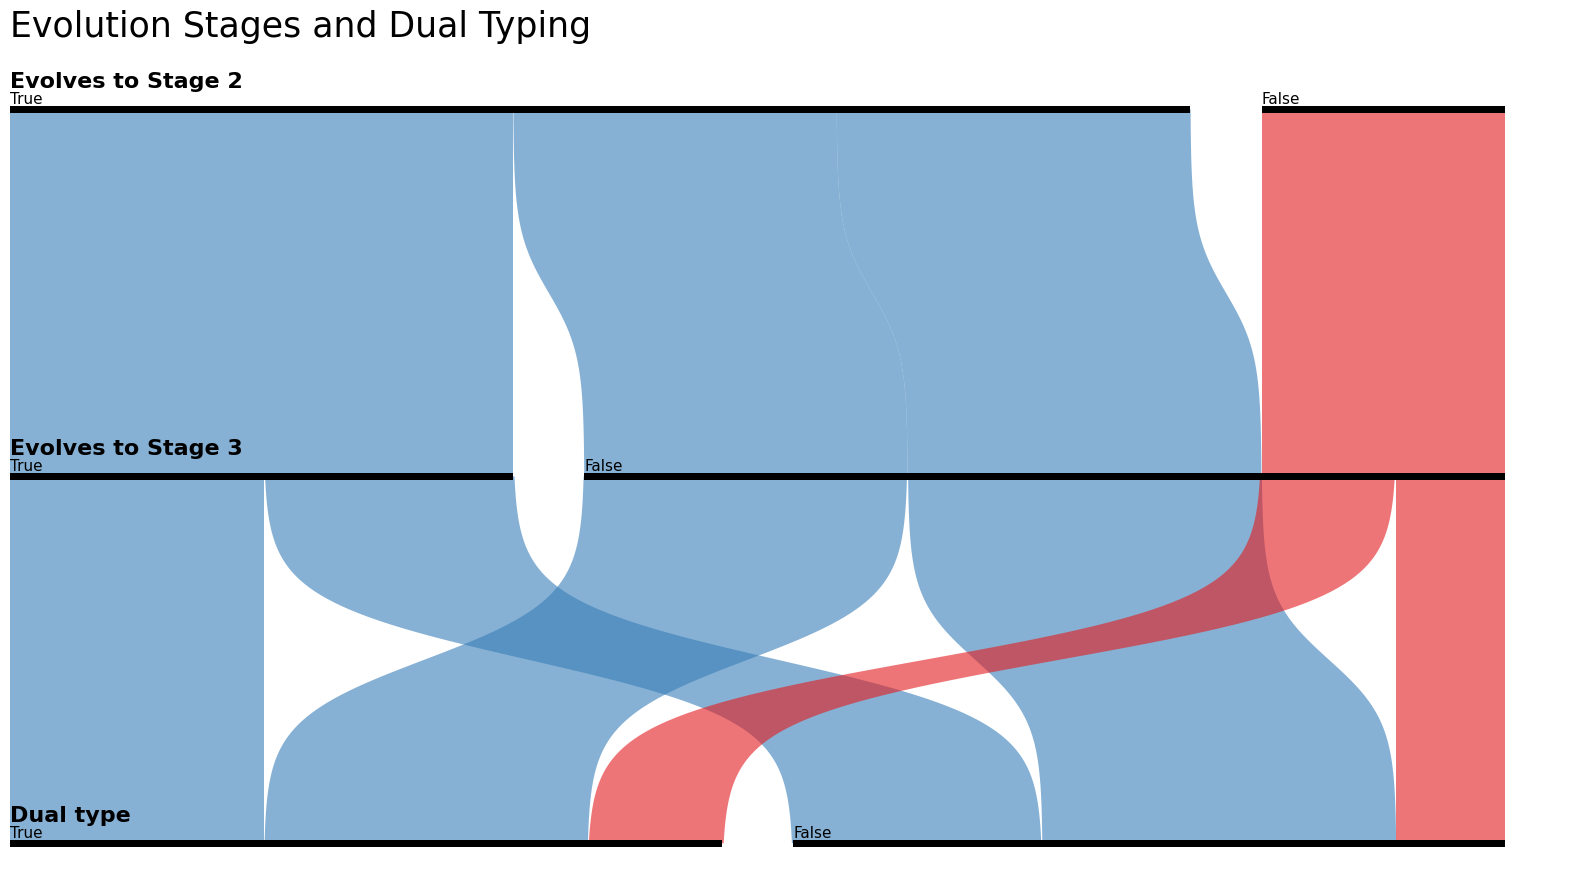

In [37]:
parallel_sets_vertical(df_final, title='Evolution Stages and Dual Typing', cat_cols=['Evolves to Stage 2', 'Evolves to Stage 3', 'Dual type'], color_col='Evolves to Stage 2', cmap='Set1')


